In [1]:
import matplotlib.pyplot as plt 
import pandas as pd             
import numpy as np              
import seaborn as sns
pd.set_option('display.max_columns', 50)

In [2]:
df = pd.read_csv('biased_leukemia_dataset.csv')

In [3]:
df.head()

,Patient_ID,Age,Gender,Country,WBC_Count,RBC_Count,Platelet_Count,Hemoglobin_Level,Bone_Marrow_Blasts,Genetic_Mutation,Family_History,Smoking_Status,Alcohol_Consumption,Radiation_Exposure,Infection_History,BMI,Chronic_Illness,Immune_Disorders,Ethnicity,Socioeconomic_Status,Urban_Rural,Leukemia_Status
0,1,52,Male,China,2698,5.36,262493,12.2,72,Yes,No,Yes,No,No,No,24.0,No,No,Ethnic_Group_B,Low,Rural,Negative
1,2,15,Female,China,4857,4.81,277877,11.9,97,Yes,No,No,No,No,No,28.7,No,No,Ethnic_Group_A,Low,Urban,Positive
2,3,72,Male,France,9614,5.17,319600,13.4,94,No,Yes,No,Yes,No,No,27.7,No,No,Ethnic_Group_B,Low,Urban,Negative
3,4,61,Male,Brazil,6278,5.41,215200,11.6,50,No,No,Yes,No,No,No,31.6,No,No,Ethnic_Group_A,Medium,Rural,Negative
4,5,21,Male,Brazil,8342,4.78,309169,14.3,28,No,No,Yes,No,No,No,22.3,No,No,Ethnic_Group_B,Low,Rural,Negative


In [4]:
df.isna().sum()

Patient_ID              0
Age                     0
Gender                  0
Country                 0
WBC_Count               0
RBC_Count               0
Platelet_Count          0
Hemoglobin_Level        0
Bone_Marrow_Blasts      0
Genetic_Mutation        0
Family_History          0
Smoking_Status          0
Alcohol_Consumption     0
Radiation_Exposure      0
Infection_History       0
BMI                     0
Chronic_Illness         0
Immune_Disorders        0
Ethnicity               0
Socioeconomic_Status    0
Urban_Rural             0
Leukemia_Status         0
dtype: int64

In [5]:
df.shape

(143194, 22)

In [6]:
df.drop_duplicates()

,Patient_ID,Age,Gender,Country,WBC_Count,RBC_Count,Platelet_Count,Hemoglobin_Level,Bone_Marrow_Blasts,Genetic_Mutation,Family_History,Smoking_Status,Alcohol_Consumption,Radiation_Exposure,Infection_History,BMI,Chronic_Illness,Immune_Disorders,Ethnicity,Socioeconomic_Status,Urban_Rural,Leukemia_Status
0,1,52,Male,China,2698,5.36,262493,12.2,72,Yes,No,Yes,No,No,No,24.0,No,No,Ethnic_Group_B,Low,Rural,Negative
1,2,15,Female,China,4857,4.81,277877,11.9,97,Yes,No,No,No,No,No,28.7,No,No,Ethnic_Group_A,Low,Urban,Positive
2,3,72,Male,France,9614,5.17,319600,13.4,94,No,Yes,No,Yes,No,No,27.7,No,No,Ethnic_Group_B,Low,Urban,Negative
3,4,61,Male,Brazil,6278,5.41,215200,11.6,50,No,No,Yes,No,No,No,31.6,No,No,Ethnic_Group_A,Medium,Rural,Negative
4,5,21,Male,Brazil,8342,4.78,309169,14.3,28,No,No,Yes,No,No,No,22.3,No,No,Ethnic_Group_B,Low,Rural,Negative
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143189,143190,11,Male,Argentina,7525,5.30,240260,12.8,74,No,Yes,No,No,No,Yes,25.5,No,No,Ethnic_Group_A,Medium,Urban,Negative
143190,143191,77,Female,China,7258,4.48,317102,13.4,51,No,No,No,Yes,No,No,27.5,No,No,Ethnic_Group_C,Low,Rural,Negative
143191,143192,22,Female,USA,6321,4.94,300353,10.3,56,No,Yes,Yes,No,No,No,22.7,No,No,Ethnic_Group_C,Medium,Rural,Negative
143192,143193,14,Female,India,8039,5.45,237054,11.9,70,No,No,No,No,No,No,21.8,Yes,No,Ethnic_Group_A,Medium,Urban,Negative


In [7]:
df.dtypes

Patient_ID                int64
Age                       int64
Gender                      str
Country                     str
WBC_Count                 int64
RBC_Count               float64
Platelet_Count            int64
Hemoglobin_Level        float64
Bone_Marrow_Blasts        int64
Genetic_Mutation            str
Family_History              str
Smoking_Status              str
Alcohol_Consumption         str
Radiation_Exposure          str
Infection_History           str
BMI                     float64
Chronic_Illness             str
Immune_Disorders            str
Ethnicity                   str
Socioeconomic_Status        str
Urban_Rural                 str
Leukemia_Status             str
dtype: object

In [8]:
num_vars = df.select_dtypes(include=['int64','float64']).columns
cat_vars = df.select_dtypes(include=['object','str']).columns

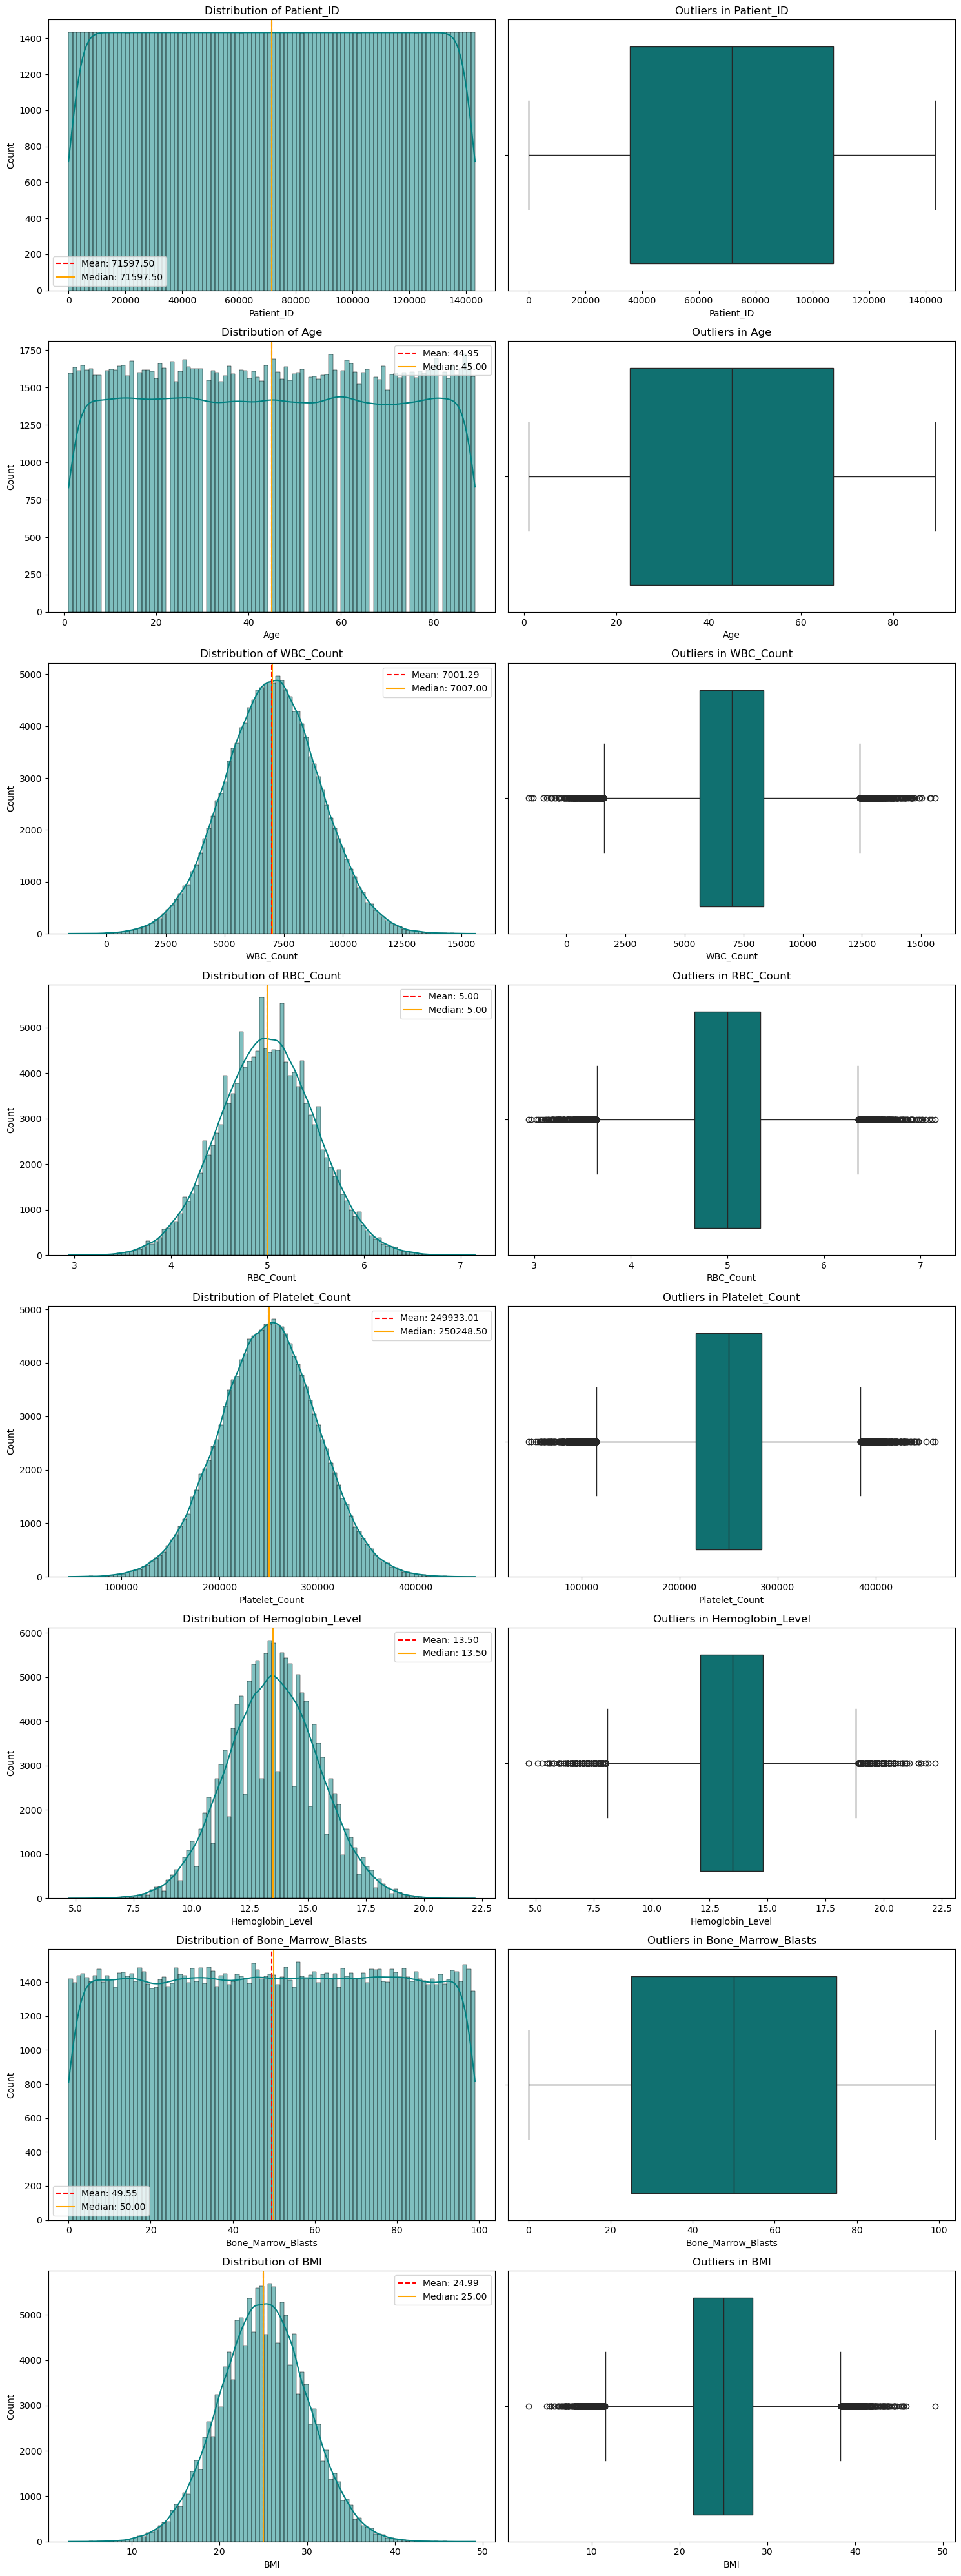

In [9]:
n_vars = len(num_vars)
fig, axes = plt.subplots(nrows=n_vars, ncols=2, figsize=(15, 5 * n_vars))

# Ensure axes is a 2D array even if there is only 1 variable
if n_vars == 1:
    axes = axes.reshape(1, 2)

for i, col in enumerate(num_vars):
    # --- Plot 1: Distribution (Histogram/Bar style) ---
    sns.histplot(df[col], kde=True,bins=100, color='teal', ax=axes[i, 0])
    axes[i, 0].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
    axes[i, 0].axvline(df[col].median(), color='orange', linestyle='-', label=f'Median: {df[col].median():.2f}')
    axes[i, 0].set_title(f'Distribution of {col}')
    axes[i, 0].legend()

    # --- Plot 2: Boxplot (Outlier detection) ---
    sns.boxplot(x=df[col], color='teal', ax=axes[i, 1])
    axes[i, 1].set_title(f'Outliers in {col}')

plt.tight_layout()
plt.show()

/tmp/ipykernel_56308/4126125427.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='viridis',
/tmp/ipykernel_56308/4126125427.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
/tmp/ipykernel_56308/4126125427.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='viridis',
/tmp/ipykernel_56308/4126125427.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i

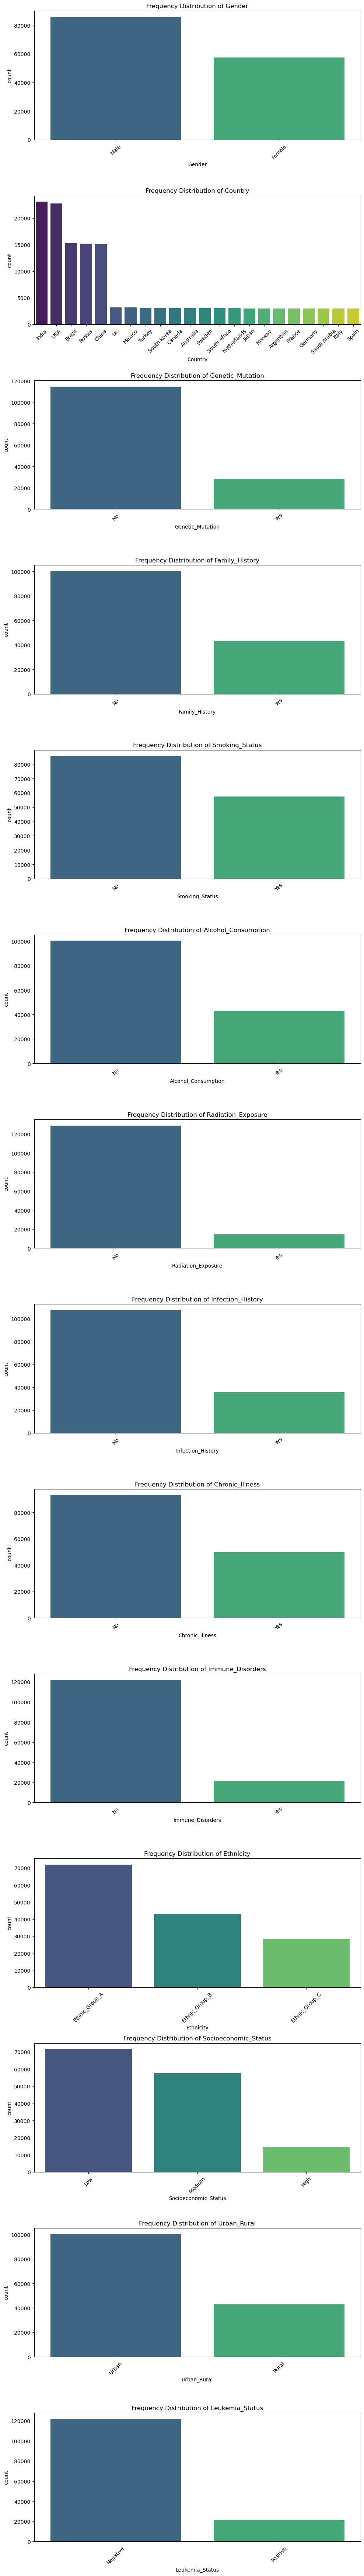

In [10]:

n_vars = len(cat_vars)
fig, axes = plt.subplots(nrows=n_vars, ncols=1, figsize=(10, 5 * n_vars))

if n_vars == 1:
    axes = [axes]

for i, col in enumerate(cat_vars):
    sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', 
                  order=df[col].value_counts().index)
    axes[i].set_title(f'Frequency Distribution of {col}')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

In [13]:
df[num_vars].corr()

,Patient_ID,Age,WBC_Count,RBC_Count,Platelet_Count,Hemoglobin_Level,Bone_Marrow_Blasts,BMI
Patient_ID,1.000000,0.001154,-0.001190,0.003927,0.001559,0.001505,0.000304,-0.002234
Age,0.001154,1.000000,0.002264,-0.003432,0.002071,-0.000936,0.004116,-0.001657
WBC_Count,-0.001190,0.002264,1.000000,0.000639,0.001954,-0.000643,-0.004365,-0.000085
RBC_Count,0.003927,-0.003432,0.000639,1.000000,-0.003046,0.000644,-0.002577,-0.001139
Platelet_Count,0.001559,0.002071,0.001954,-0.003046,1.000000,-0.002083,0.004116,-0.000708
Hemoglobin_Level,0.001505,-0.000936,-0.000643,0.000644,-0.002083,1.000000,-0.000273,0.001591
Bone_Marrow_Blasts,0.000304,0.004116,-0.004365,-0.002577,0.004116,-0.000273,1.000000,0.002438
BMI,-0.002234,-0.001657,-0.000085,-0.001139,-0.000708,0.001591,0.002438,1.000000


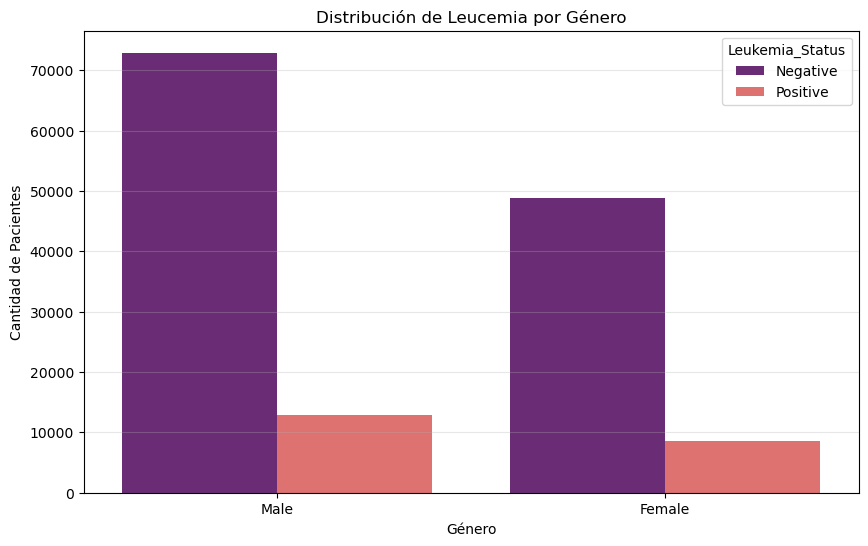

In [17]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Gender', hue='Leukemia_Status', palette='magma')
plt.title('Distribución de Leucemia por Género')
plt.xlabel('Género')
plt.ylabel('Cantidad de Pacientes')
plt.grid(axis='y', alpha=0.3)
plt.show()

/tmp/ipykernel_56308/3141403805.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Leukemia_Status', y='BMI', ax=axes[0], palette='Set2')
/tmp/ipykernel_56308/3141403805.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Leukemia_Status', y='Age', ax=axes[1], palette='Set2')


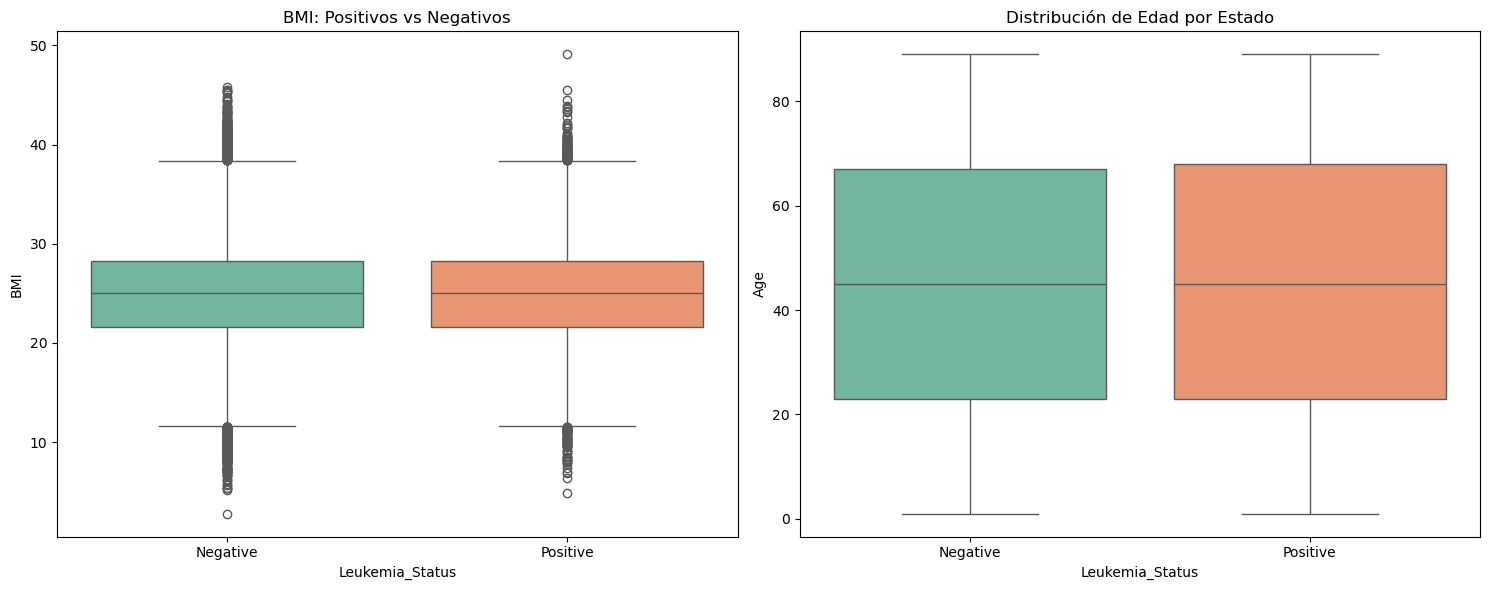

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(data=df, x='Leukemia_Status', y='BMI', ax=axes[0], palette='Set2')
axes[0].set_title('BMI: Positivos vs Negativos')

sns.boxplot(data=df, x='Leukemia_Status', y='Age', ax=axes[1], palette='Set2')
axes[1].set_title('Distribución de Edad por Estado')

plt.tight_layout()
plt.show()

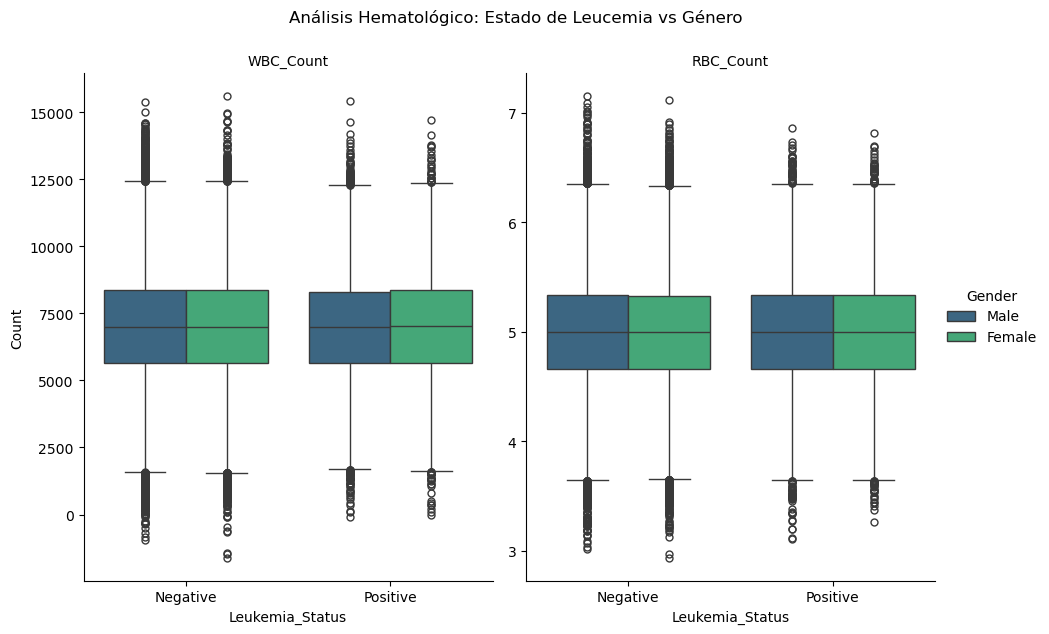

In [19]:
blood_counts = df.melt(id_vars=['Leukemia_Status', 'Gender'], 
                       value_vars=['WBC_Count', 'RBC_Count'], 
                       var_name='Cell_Type', value_name='Count')

g = sns.catplot(data=blood_counts, x='Leukemia_Status', y='Count', hue='Gender', col='Cell_Type', kind='box',palette='viridis', height=6, aspect=0.8, sharey=False)

g.set_titles("{col_name}")
g.fig.suptitle('Análisis Hematológico: Estado de Leucemia vs Género', y=1.05)
plt.show()